In [1]:
!pip -q install datasets transformers evaluate accelerate sentence-transformers faiss-cpu scikit-learn pandas numpy matplotlib seaborn plotly umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.8 MB/s eta 0:00:00:00:0100:01


In [ ]:
import os
import random
import torch
import faiss
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from datasets import load_dataset, Dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    pipeline
)

from sentence_transformers import SentenceTransformer, CrossEncoder

warnings.filterwarnings('ignore')

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1. Configuration

In [4]:
ENGLISH_ONLY = True
TEXT_MAX_LEN = 256
TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "Tobi-Bueck/customer-support-tickets"
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RERANKER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

OUTPUT_DIR = "artifacts_supportmind"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load dataset

In [5]:
raw_data = load_dataset(DATASET_NAME)
raw_data

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})

In [6]:
df = raw_data["train"].to_pandas()
print(df.shape)

(61765, 16)


In [7]:
df.head(1)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None


## 3. Inspect schema and map important columns

In [ ]:
def find_col(columns, candidates):
    lowered = {c.lower(): c for c in columns}
    for cand in candidates:
        for c in columns:
            if c.lower() == cand.lower():
                return c
        
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

all_cols = list(df.columns)

In [ ]:
subject_col = find_col(all_cols, ["subject"])
body_col = find_col(all_cols, ["body", "text", "email body"])
queue_col = find_col(all_cols, ["queue", "department"])
priority_col = find_col(all_cols, ["priority"])
language_col = find_col(all_cols, ["language", "lang"])
answer_col = find_col(all_cols, ["answer", "response", "reply"])
type_col = find_col(all_cols, ["type"])
business_type_col = find_col(all_cols, ["business type", "business_type"])

In [ ]:
tag_cols = [c for c in all_cols if "tag" in c.lower()]
column_map = {
    "subject_col": subject_col,
    "body_col": body_col,
    "queue_col": queue_col,
    "priority_col": priority_col,
    "language_col": language_col,
    "answer_col": answer_col,
    "type_col": type_col,
    "business_type_col": business_type_col,
    "tag_cols": tag_cols,
}

column_map

{'subject_col': 'subject',
 'body_col': 'body',
 'queue_col': 'queue',
 'priority_col': 'priority',
 'language_col': 'language',
 'answer_col': 'answer',
 'type_col': 'type',
 'business_type_col': None,
 'tag_cols': ['tag_1',
  'tag_2',
  'tag_3',
  'tag_4',
  'tag_5',
  'tag_6',
  'tag_7',
  'tag_8']}

In [11]:
required = [subject_col, body_col, queue_col, priority_col, language_col, answer_col]

missing = [c for c in required if c is None]
if missing:
    raise ValueError(f"columns were not found")

## 4. Basic cleaning and feature creation

In [12]:
work_df = df.copy()

for col in [subject_col, body_col, queue_col, priority_col, language_col, answer_col]:
    work_df[col] = work_df[col].astype(str).fillna("")

work_df["text"] = (
    work_df[subject_col].fillna("").astype(str).str.strip() + "\n\n" + work_df[body_col].fillna("").astype(str).str.strip()
)

In [13]:
work_df["text"] = work_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

work_df["answer_col"] = work_df[answer_col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()


work_df = work_df[work_df["text"].str.len() > 20].copy()
work_df = work_df[work_df[queue_col].str.len() > 0].copy()
work_df = work_df[work_df["answer_col"].str.len() > 0].copy()

In [14]:
if ENGLISH_ONLY:
    work_df = work_df[work_df[language_col].str.lower().isin(["en", "english"])].copy()

work_df = work_df.reset_index(drop=True)


print(work_df.shape)
work_df[[subject_col, body_col, queue_col, priority_col, language_col, answer_col]].head(2)

(28259, 18)


,subject,body,queue,priority,language,answer
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,en,"Thank you for reaching out, <name>. We are awa..."
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,en,Thank you for your inquiry. Our products suppo...


## 5. EDA

In [15]:
print("Unique queues:", work_df[queue_col].nunique())
print("Unique priorities:", work_df[priority_col].nunique())
print("Languages:", work_df[language_col].value_counts().to_dict())

display(work_df[[queue_col, priority_col]].describe(include='object'))

Unique queues: 10
Unique priorities: 3
Languages: {'en': 28259}


,queue,priority
count,28259,28259
unique,10,3
top,Technical Support,medium
freq,8149,11568


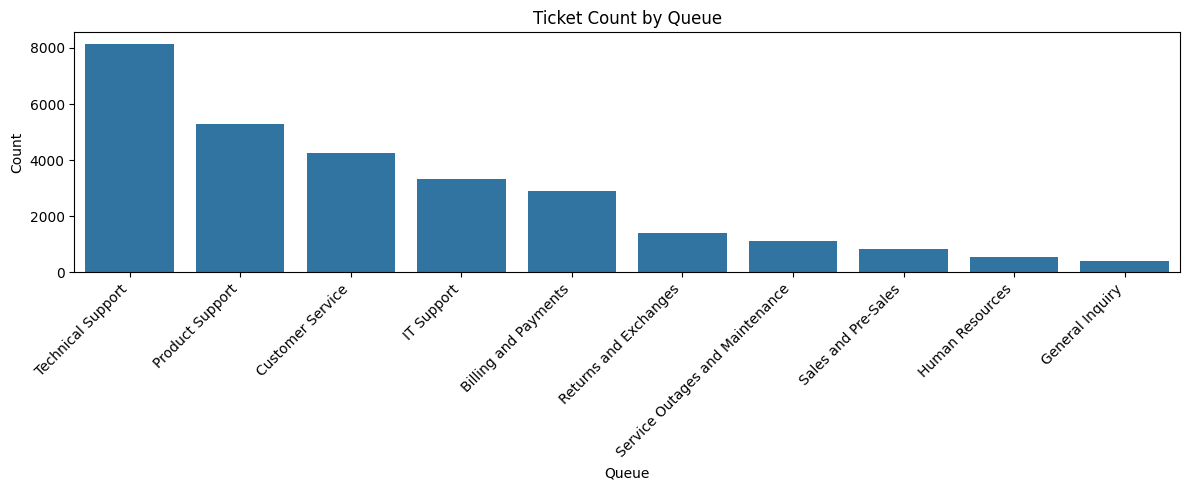

In [16]:
queue_counts = work_df[queue_col].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=queue_counts.index, y=queue_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Ticket Count by Queue")
plt.xlabel("Queue")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

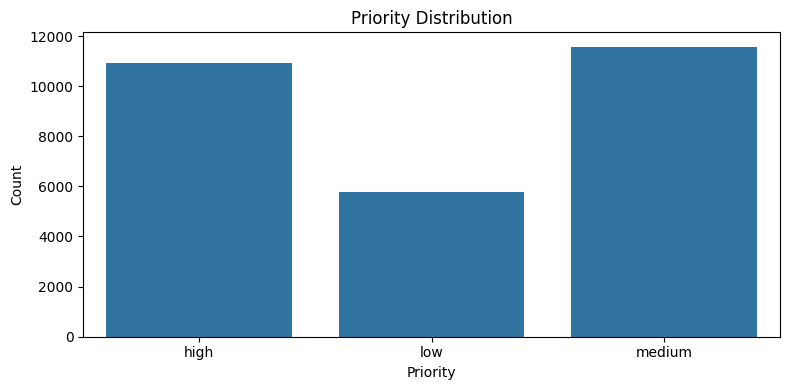

In [18]:
priority_counts = work_df[priority_col].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=priority_counts.index.astype(str), y=priority_counts.values)
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

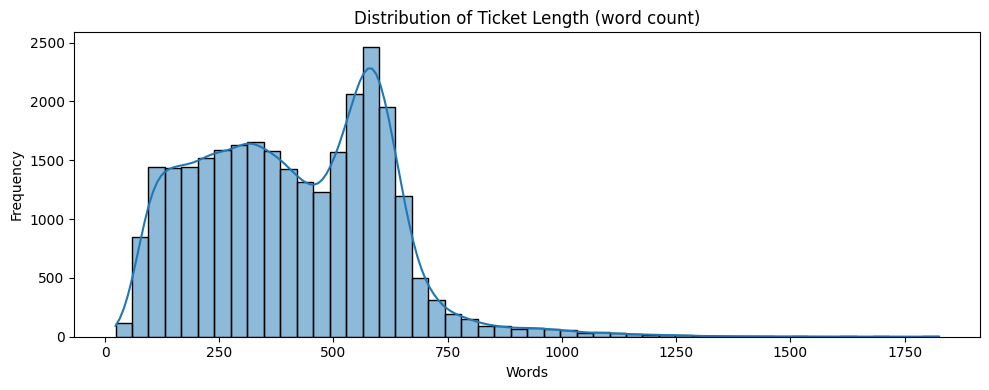

In [19]:
work_df["text_len"] = work_df["text"].str.strip().apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(work_df["text_len"], bins=50, kde=True)
plt.title("Distribution of Ticket Length (word count)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [21]:
valid_labels = work_df[queue_col].value_counts()
valid_labels = valid_labels.index.tolist()

model_df = work_df[work_df[queue_col].isin(valid_labels)].copy()
model_df = model_df.reset_index(drop=True)

print("Remaining rows:", model_df.shape[0])
print("Remaining queues:", model_df[queue_col].nunique())
model_df[queue_col].value_counts()

Remaining rows: 28259
Remaining queues: 10


,count
queue,
Technical Support,8149
Product Support,5305
Customer Service,4269
IT Support,3333
Billing and Payments,2895
Returns and Exchanges,1402
Service Outages and Maintenance,1106
Sales and Pre-Sales,843
Human Resources,553


## 7. Train / validation / test split

In [23]:
train_df, tmp_df = train_test_split(
    model_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=model_df[queue_col]
)

valid_df, test_df = train_test_split(
    tmp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=tmp_df[queue_col]
)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

Train: (19781, 19)
Valid: (4239, 19)
Test : (4239, 19)


## 8. Encode labels

In [24]:
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df[queue_col])
valid_df["label"] = label_encoder.transform(valid_df[queue_col])
test_df["label"] = label_encoder.transform(test_df[queue_col])

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

for i, label in id2label.items():
    print(i, "->", label)

0 -> Billing and Payments
1 -> Customer Service
2 -> General Inquiry
3 -> Human Resources
4 -> IT Support
5 -> Product Support
6 -> Returns and Exchanges
7 -> Sales and Pre-Sales
8 -> Service Outages and Maintenance
9 -> Technical Support


# Part A — Classical Baseline

In [25]:
baseline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            max_features=80000,
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ]
)

baseline.fit(train_df["text"], train_df["label"])
baseline_valid_preds = baseline.predict(valid_df["text"])
baseline_test_preds = baseline.predict(test_df["text"])

In [26]:
def evaluate_multiclass(y_true, y_pred, name):
    metrics = {
        "accuracy" : accuracy_score(y_true, y_pred),
        "f1_weighted" : f1_score(y_true, y_pred, average="weighted"),
        "f1_macro" : f1_score(y_true, y_pred, average="macro")
    }
    print(name, metrics)
    return metrics

baseline_valid_metrics = evaluate_multiclass(valid_df["label"], baseline_valid_preds, "Baseline Valid")
baseline_test_metrics = evaluate_multiclass(test_df["label"], baseline_test_preds, "Baseline Test")

Baseline Valid {'accuracy': 0.5638122198631753, 'f1_weighted': 0.5639098624458543, 'f1_macro': 0.5811941452424889}
Baseline Test {'accuracy': 0.5598018400566172, 'f1_weighted': 0.559943779951271, 'f1_macro': 0.572278809688229}


In [27]:
print(classification_report(
    test_df["label"],
    baseline_test_preds,
    target_names=label_encoder.classes_
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.79      0.82      0.80       434
               Customer Service       0.51      0.48      0.49       640
                General Inquiry       0.44      0.53      0.48        60
                Human Resources       0.65      0.77      0.71        83
                     IT Support       0.42      0.53      0.47       500
                Product Support       0.57      0.45      0.51       796
          Returns and Exchanges       0.44      0.66      0.53       211
            Sales and Pre-Sales       0.40      0.70      0.51       127
Service Outages and Maintenance       0.56      0.77      0.65       166
              Technical Support       0.64      0.52      0.57      1222

                       accuracy                           0.56      4239
                      macro avg       0.54      0.62      0.57      4239
                   weighted avg       0.57      0

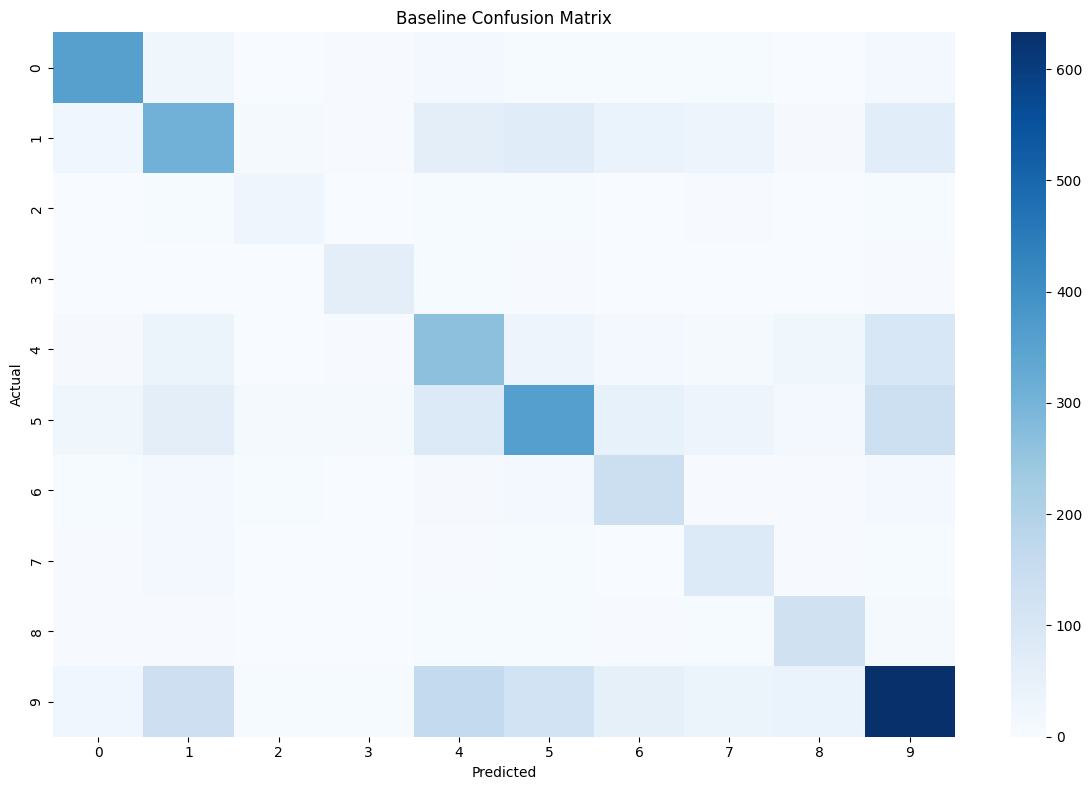

In [28]:
cm = confusion_matrix(test_df["label"], baseline_test_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Part B — Transformer Fine-Tuning

In [29]:
train_hf = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
valid_hf = Dataset.from_pandas(valid_df[["text", "label"]], preserve_index=False)
test_hf = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [30]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=TEXT_MAX_LEN,
    )

train_tokn = train_hf.map(tokenize_batch, batched=True)
valid_tokn = valid_hf.map(tokenize_batch, batched=True)
test_tokn = test_hf.map(tokenize_batch, batched=True)

Map:   0%|          | 0/19781 [00:00<?, ? examples/s]

Map:   0%|          | 0/4239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4239 [00:00<?, ? examples/s]

In [31]:
f1_metric = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy" : acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/queue_classifier",
    learning_rate=2e-5,
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=4,
    
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    
    eval_strategy="epoch",
    save_strategy="epoch",
    
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    gradient_checkpointing=False,
    
    greater_is_better=True,
    fp16=True,
    
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=42,
)

callbacks = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokn,
    eval_dataset=valid_tokn,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[callbacks]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,3.313904,1.604165,0.408823,0.358540,0.256588
2,2.981484,1.477890,0.459778,0.417687,0.340329
3,2.695157,1.417524,0.486435,0.457146,0.375835
4,2.459153,1.391243,0.506959,0.486370,0.408826


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2476, training_loss=2.9446050431308533, metrics={'train_runtime': 364.735, 'train_samples_per_second': 216.936, 'train_steps_per_second': 6.788, 'total_flos': 3078464290386300.0, 'train_loss': 2.9446050431308533, 'epoch': 4.0})

In [37]:
transformer_valid_metrics = trainer.evaluate(valid_tokn)
transformer_test_metrics = trainer.evaluate(test_tokn)
transformer_valid_metrics, transformer_test_metrics

({'eval_loss': 1.3912429809570312,
  'eval_accuracy': 0.5069591884878509,
  'eval_f1_weighted': 0.4863703726050907,
  'eval_f1_macro': 0.40882622987811956,
  'eval_runtime': 5.4367,
  'eval_samples_per_second': 779.695,
  'eval_steps_per_second': 24.463,
  'epoch': 4.0},
 {'eval_loss': 1.3726967573165894,
  'eval_accuracy': 0.5133286152394433,
  'eval_f1_weighted': 0.49328898742579924,
  'eval_f1_macro': 0.41713656059438475,
  'eval_runtime': 5.8,
  'eval_samples_per_second': 730.866,
  'eval_steps_per_second': 22.931,
  'epoch': 4.0})